In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Definição do domínio e da malha

Consideramos o domínio

$$
\Omega=(-2,2)
$$

e uma malha uniforme com passo

$$
h=0.5.
$$

Os nós são definidos por

$$
x_i=-2+ih,
\qquad i=0,1,\dots,8.
$$

Como o comprimento do intervalo é \(4\), temos

$$
N_e=\frac{4}{0.5}=8
$$

elementos e, portanto, \(9\) nós.

In [3]:
# Domínio e malha
a = -2.0
b = 2.0
h = 0.5

nos = np.arange(a, b + h, h)
num_nos = len(nos)
num_elementos = num_nos - 1

## Dados do problema

Escrevemos a equação como

$$
-u''(x)=f(x),
$$

onde

$$
f(x)=\pi^2\sin(\pi x).
$$

A condição de Dirichlet é

$$
u(-2)=1,
$$

e a condição de Neumann é

$$
u'(2)=\pi+1.
$$

Também definimos a solução exata para comparar com a aproximação numérica:

$$
u(x)=\sin(\pi x)+x+3.
$$

In [4]:
# Dados do problema
def f(x):
    return np.pi**2 * np.sin(np.pi * x)

def solucao_exata(x):
    return np.sin(np.pi * x) + x + 3

valor_dirichlet = 1.0
valor_neumann = np.pi + 1.0

# Matrizes globais
M = np.zeros((num_nos, num_nos))
F = np.zeros(num_nos)

# Quadratura de Gauss com 2 pontos no elemento de referência [-1, 1]
pontos_gauss = np.array([-1 / np.sqrt(3), 1 / np.sqrt(3)])
pesos_gauss = np.array([1.0, 1.0])

Como $u_h$ é escrito na base nodal, temos

$$
u_h(x)
=
\sum_{j=0}^{8} U_j\varphi_j(x),
$$

onde $\varphi_j$ são as funções base de Lagrange e $U_j$ são os coeficientes desconhecidos da aproximação.

Substituindo essa expressão na formulação variacional discreta,

$$
\int_{-2}^{2}u_h'(x)v_h'(x)\,dx
=
\int_{-2}^{2}\pi^2\sin(\pi x)v_h(x)\,dx
+
(\pi+1)v_h(2),
\qquad \forall v_h\in V_h,
$$

e tomando como funções teste as próprias funções da base,

$$
v_h=\varphi_i,
\qquad i=1,\dots,8,
$$

obtemos um sistema linear da forma

$$
MU=F.
$$

As entradas da matriz são dadas por

$$
M_{ij}
=
\int_{-2}^{2}
\varphi_j'(x)\varphi_i'(x)\,dx,
$$

e as entradas do vetor do lado direito são

$$
F_i
=
\int_{-2}^{2}
\pi^2\sin(\pi x)\varphi_i(x)\,dx
+
(\pi+1)\varphi_i(2).
$$

Como a condição de Dirichlet impõe

$$
u_h(-2)=1,
$$

e o primeiro nó é $x_0=-2$, temos

$$
U_0=1.
$$

Portanto, as incógnitas livres do sistema são

$$
U_1,U_2,\dots,U_8.
$$

## Montagem elemento a elemento

Em cada elemento

$$
M_e=[x_e,x_{e+1}],
$$

usamos funções de Lagrange lineares locais. No elemento de referência, elas são

$$
\varphi_0(\xi)=\frac{1-\xi}{2},
\qquad
\varphi_1(\xi)=\frac{1+\xi}{2}.
$$

A matriz local (onde os elementos são não nulos para o elemento $e$, ou seja, seus vizinhos) para elementos lineares é

$$
M^{(e)}
=
\frac{1}{h_e}
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}.
$$

Depois, cada contribuição local é somada nas posições correspondentes da matriz global.

## Resolução do sistema linear

Agora resolvemos o sistema reduzido

$$
M_{\text{red}}U_{\text{livre}}=F_{\text{red}}.
$$

Depois reconstruímos o vetor completo da solução, incluindo o valor conhecido

$$
U_0=1.
$$

In [5]:
# Montagem elemento a elemento
for e in range(num_elementos):
    x_esq = nos[e]
    x_dir = nos[e + 1]
    h_e = x_dir - x_esq

    M_local = (1 / h_e) * np.array([
        [1, -1],
        [-1, 1]
    ])

    F_local = np.zeros(2)

    # Integração numérica
    for ponto, peso in zip(pontos_gauss, pesos_gauss):
        x = ((x_dir + x_esq) / 2) + ((h_e / 2) * ponto)
        jacobiano = h_e / 2

        phi_0 = (1 - ponto) / 2
        phi_1 = (1 + ponto) / 2

        phi = np.array([phi_0, phi_1])

        F_local += peso * f(x) * phi * jacobiano

    indices = [e, e + 1]

    # Montagem global das matrizes locais por elemento
    for i_local, i_global in enumerate(indices):
        F[i_global] += F_local[i_local]

        for j_local, j_global in enumerate(indices):
            M[i_global, j_global] += M_local[i_local, j_local]

# Termo de Neumann em x = 2
# Como phi_8(2) = 1, adicionamos (pi + 1) ao último grau de liberdade
F[-1] += valor_neumann

#condição de Dirichlet u(-2) = 1
indices_livres = np.arange(1, num_nos)

M_reduzida = M[np.ix_(indices_livres, indices_livres)]
F_reduzido = F[indices_livres] - M[np.ix_(indices_livres, [0])].flatten() * valor_dirichlet

# Resolução do sistema linear
U = np.zeros(num_nos)
U[0] = valor_dirichlet
U[indices_livres] = np.linalg.solve(M_reduzida, F_reduzido)

In [6]:
# Solução exata nos nós
U_exata = solucao_exata(nos)

# Erro nodal
erro = np.abs(U - U_exata)

print("Nós:")
print(nos)

print("\nSolução aproximada:")
print(U)

print("\nSolução exata:")
print(U_exata)

print("\nErro nós:")
print(erro)

print("\nErro máximo nós:")
print(np.max(erro))

Nós:
[-2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]

Solução aproximada:
[1.         2.50723408 2.00479843 1.50236277 3.00959685 4.51683094
 4.01439528 3.51195962 5.01919371]

Solução exata:
[1.  2.5 2.  1.5 3.  4.5 4.  3.5 5. ]

Erro nós:
[2.22044605e-16 7.23408259e-03 4.79842651e-03 2.36277043e-03
 9.59685302e-03 1.68309356e-02 1.43952795e-02 1.19596234e-02
 1.91937060e-02]

Erro máximo nós:
0.01919370603529913


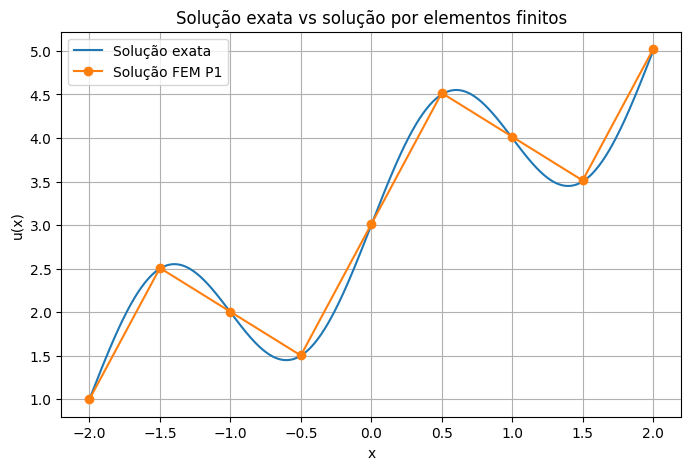

In [7]:
x_plot = np.linspace(a, b, 500)
u_exata_plot = solucao_exata(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, u_exata_plot, label="Solução exata")
plt.plot(nos, U, "o-", label="Solução FEM P1")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Solução exata vs solução por elementos finitos")
plt.grid(True)
plt.legend()
plt.show()


# Lista 2 — Exercício 1

Nesta parte, usamos a implementação anterior como base e acrescentamos:

1. a dedução das estimativas de erro na norma da energia e na norma $L^2(-2,2)$;
2. um estudo numérico de convergência em malhas uniformes.



In [ ]:

#Funções para resolver o problema em uma malha uniforme qualquer

import numpy as np
import matplotlib.pyplot as plt

def f_problema(x):
    return np.pi**2 * np.sin(np.pi * x)

def solucao_exata_problema(x):
    return np.sin(np.pi * x) + x + 3

def derivada_solucao_exata(x):
    return np.pi * np.cos(np.pi * x) + 1

def resolver_fem_p1(num_elementos, a=-2.0, b=2.0):
    """
        -u'' = pi^2 sin(pi x)
        u(-2) = 1
        u'(2) = pi + 1
    """
    nos = np.linspace(a, b, num_elementos + 1)
    num_nos = len(nos)

    matriz_rigidez = np.zeros((num_nos, num_nos))
    vetor_forca = np.zeros(num_nos)

    pontos_gauss, pesos_gauss = np.polynomial.legendre.leggauss(8)

    for elemento in range(num_elementos):
        x_esq = nos[elemento]
        x_dir = nos[elemento + 1]
        h_elemento = x_dir - x_esq

        matriz_local = (1 / h_elemento) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0],
        ])

        vetor_local = np.zeros(2)

        for ponto, peso in zip(pontos_gauss, pesos_gauss):
            x = (x_esq + x_dir) / 2 + (h_elemento / 2) * ponto
            jacobiano = h_elemento / 2

            phi = np.array([
                (1 - ponto) / 2,
                (1 + ponto) / 2,
            ])

            vetor_local += peso * f_problema(x) * phi * jacobiano

        indices = [elemento, elemento + 1]

        for i_local, i_global in enumerate(indices):
            vetor_forca[i_global] += vetor_local[i_local]

            for j_local, j_global in enumerate(indices):
                matriz_rigidez[i_global, j_global] += matriz_local[i_local, j_local]

    valor_dirichlet = 1.0
    valor_neumann = np.pi + 1.0

    # Termo de Neumann em x = 2
    vetor_forca[-1] += valor_neumann

    indices_livres = np.arange(1, num_nos)

    matriz_reduzida = matriz_rigidez[np.ix_(indices_livres, indices_livres)]
    vetor_reduzido = (
        vetor_forca[indices_livres]
        - matriz_rigidez[np.ix_(indices_livres, [0])].flatten() * valor_dirichlet
    )

    solucao = np.zeros(num_nos)
    solucao[0] = valor_dirichlet
    solucao[indices_livres] = np.linalg.solve(matriz_reduzida, vetor_reduzido)

    return nos, solucao


def avaliar_solucao_fem_p1(x, nos, coeficientes):
    x = np.asarray(x)
    valores = np.zeros_like(x, dtype=float)

    for i, xi in enumerate(x):
        if xi <= nos[0]:
            valores[i] = coeficientes[0]
            continue

        if xi >= nos[-1]:
            valores[i] = coeficientes[-1]
            continue

        elemento = np.searchsorted(nos, xi) - 1
        elemento = max(0, min(elemento, len(nos) - 2))

        x_esq = nos[elemento]
        x_dir = nos[elemento + 1]
        h_elemento = x_dir - x_esq

        phi_esq = (x_dir - xi) / h_elemento
        phi_dir = (xi - x_esq) / h_elemento

        valores[i] = (
            coeficientes[elemento] * phi_esq
            + coeficientes[elemento + 1] * phi_dir
        )

    return valores


def calcular_erros(nos, coeficientes):
    erro_energia_quadrado = 0.0
    erro_l2_quadrado = 0.0

    pontos_gauss, pesos_gauss = np.polynomial.legendre.leggauss(8)

    for elemento in range(len(nos) - 1):
        x_esq = nos[elemento]
        x_dir = nos[elemento + 1]
        h_elemento = x_dir - x_esq

        u_esq = coeficientes[elemento]
        u_dir = coeficientes[elemento + 1]
        derivada_uh = (u_dir - u_esq) / h_elemento

        for ponto, peso in zip(pontos_gauss, pesos_gauss):
            x = (x_esq + x_dir) / 2 + (h_elemento / 2) * ponto
            jacobiano = h_elemento / 2

            phi_esq = (1 - ponto) / 2
            phi_dir = (1 + ponto) / 2

            uh = u_esq * phi_esq + u_dir * phi_dir
            u = solucao_exata_problema(x)
            du = derivada_solucao_exata(x)

            erro_l2_quadrado += peso * (u - uh)**2 * jacobiano
            erro_energia_quadrado += peso * (du - derivada_uh)**2 * jacobiano

    erro_energia = np.sqrt(erro_energia_quadrado)
    erro_l2 = np.sqrt(erro_l2_quadrado)

    return erro_energia, erro_l2


In [9]:

# Estudo de convergência h

malhas = np.array([8, 16, 32, 64, 128, 256])
hs = []
erros_energia = []
erros_l2 = []

for num_elementos in malhas:
    nos_h, solucao_h = resolver_fem_p1(num_elementos)
    h = (nos_h[-1] - nos_h[0]) / num_elementos

    erro_energia, erro_l2 = calcular_erros(nos_h, solucao_h)

    hs.append(h)
    erros_energia.append(erro_energia)
    erros_l2.append(erro_l2)

hs = np.array(hs)
erros_energia = np.array(erros_energia)
erros_l2 = np.array(erros_l2)

coef_energia = np.polyfit(np.log(hs), np.log(erros_energia), 1)
coef_l2 = np.polyfit(np.log(hs), np.log(erros_l2), 1)

taxa_energia = coef_energia[0]
taxa_l2 = coef_l2[0]

print("Tabela de convergência")
print("-" * 72)
print(f"{'N elementos':>12} {'h':>12} {'erro energia':>18} {'erro L2':>18}")
print("-" * 72)

for num_elementos, h, erro_e, erro_l2 in zip(malhas, hs, erros_energia, erros_l2):
    print(f"{num_elementos:12d} {h:12.6f} {erro_e:18.8e} {erro_l2:18.8e}")

print("-" * 72)
print(f"Inclinação ajustada para a norma da energia: {taxa_energia:.4f}")
print(f"Inclinação ajustada para a norma L2: {taxa_l2:.4f}")


Tabela de convergência
------------------------------------------------------------------------
 N elementos            h       erro energia            erro L2
------------------------------------------------------------------------
           8     0.500000     1.93370339e+00     3.01753967e-01
          16     0.250000     9.97016950e-01     7.85686955e-02
          32     0.125000     5.02363539e-01     1.98418398e-02
          64     0.062500     2.51666317e-01     4.97300268e-03
         128     0.031250     1.25893810e-01     1.24403559e-03
         256     0.015625     6.29544893e-02     3.11057970e-04
------------------------------------------------------------------------
Inclinação ajustada para a norma da energia: 0.9902
Inclinação ajustada para a norma L2: 1.9871


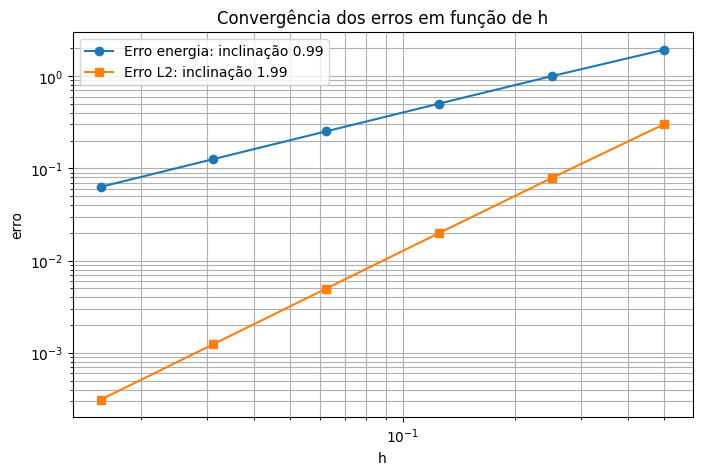

In [10]:

# Gráfico log-log dos erros

plt.figure(figsize=(8, 5))
plt.loglog(hs, erros_energia, "o-", label=f"Erro energia: inclinação {taxa_energia:.2f}")
plt.loglog(hs, erros_l2, "s-", label=f"Erro L2: inclinação {taxa_l2:.2f}")
plt.xlabel("h")
plt.ylabel("erro")
plt.title("Convergência dos erros em função de h")
plt.grid(True, which="both")
plt.legend()
plt.show()
